# 1D FWI implementation via ODIL

In this notebook, I will extend what I have learnt of ODIL from reproducing Figure 1 in the [`/reproduction`](./../reproduction/) notebooks. Our task will be to jointly optimise for an amplitude field and a wavespeed field using the ODIL framework. This will involve introducing a source term, the concept of 'receievers' (discrete observation points), and a data misfit.

To start, we can update our `Wavefield` class to include a wavespeed model in its data vector. It is important we keep the wavespeed and ampltiude data together. If we do not perform a joint optimisation and instead optimise the two field separately, the wave equation solve will be chasing an expired wavespeed model. 

In [4]:
from dataclasses import dataclass, field
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt

In [29]:
@dataclass
class Wavefield:
    # spatial data
    x_0: float = -1.0
    x_I: float = 1.0
    I: int = 25
    L: float = field(init=False)
    dx: float = field(init=False)

    # temporal data
    t_0: float = 0.0
    t_N: float = 1.0
    N: int = 25
    T: float = field(init=False)
    dt: float = field(init=False)

    # actual data
    init_amplitude: np.ndarray | None = None  # data to initialise with
    init_wavespeed: np.ndarray | None = None
    wavespeed_idx: float = field(init=False) # where wavespeed starts in internal data

    _data: np.ndarray = field(init=False)  # internal data
    _shape: Tuple[int, int] = field(init=False)  # length of domain object

    def __post_init__(self):
        # compute lengths and spacings
        self.L = self.x_I - self.x_0
        self.dx = self.L / (self.I - 1)

        self.T = self.t_N - self.t_0
        self.dt = self.T / (self.N - 1)

        self._shape = (self.N, self.I)  # t, x

        self.wavespeed_idx = self.N * self.I 

        # receieve initial values or init arrays
        amplitude = (
            np.zeros(shape=(self._shape), dtype=float).flatten() if self.init_amplitude is None 
            else np.asarray(self.init_amplitude, dtype=float).flatten()
            )
        wavespeed = (np.ones(shape=(self.I)) if self.init_wavespeed is None 
                    else np.asarray(self.init_wavespeed, dtype=float).flatten()
                    )

        # concatenate the two
        # note: wavespeed starts at NxI
        self._data = np.concatenate((amplitude, wavespeed))

    # convention: space index i, time index n
    def __getitem__(self, key):
        i, n = key
        return self._data[i + self.I * n]

    def __setitem__(self, key, value):
        i, n = key
        self._data[i + self.I * n] = value

    def __sub__(self, other):
        return self._data - other._data

    def __pow__(self, other):
        return self._data**other

    @property
    def data(self):
        return self._data
    
    @property
    def amplitude(self):
        return self._data[:self.wavespeed_idx]
    
    @property
    def wavespeed(self):
        return self._data[self.wavespeed_idx:]

    @property
    def shape(self):
        return self._shape

    def show_domain(self, title: str = "Exact solution") -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        umax = np.abs(self.amplitude).max()
        im = ax.imshow(
            self.amplitude.reshape(self.N, self.I),
            extent=(self.x_0, self.x_I, self.t_N, self.t_0),  # [xmin, xmax, tmax, tmin]
            cmap="RdBu_r",
            vmin=-umax,
            vmax=umax,
            aspect=4,
        )

        plt.colorbar(im, ax=ax, label="u(x, t)")
        ax.set_xlabel("x")
        ax.set_ylabel("t")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    def show_model(self, title: str = "Wavespeed") -> None:
        fig, ax = plt.subplots(figsize=(8, 5))
        xs = np.linspace(self.x_0, self.x_I, self.I)
        ax.plot(xs, self.wavespeed)
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("c")
        plt.show()

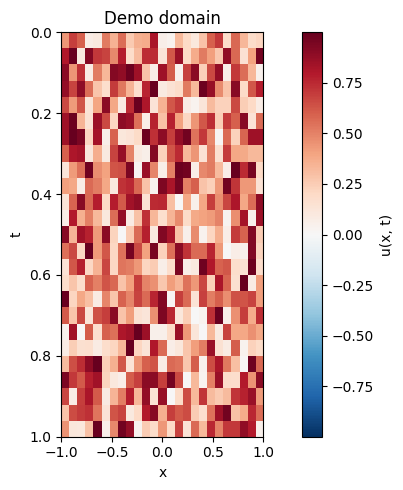

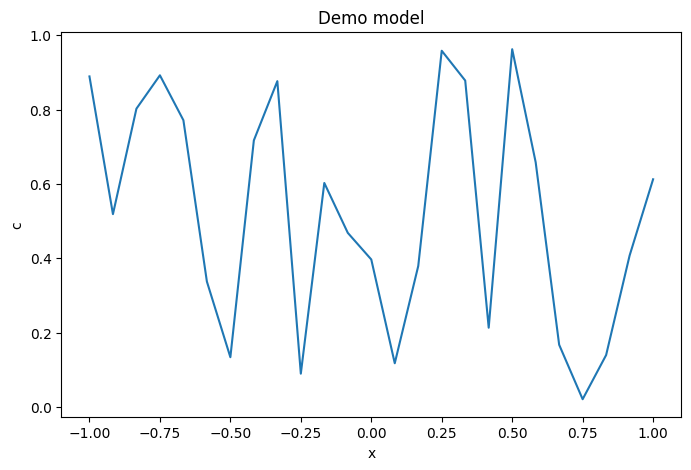

In [30]:
u = Wavefield(init_wavespeed=np.random.rand(25, 25), init_amplitude=np.random.rand(25))
u.show_domain(title='Demo domain')
u.show_model(title='Demo model')

Now, we can start to work on our loss formulation. There are a few things we need to do:

- Previously, we used `c=1`. Now, we need to update our residual to use the wavespeed model at the interior points.
- We used analytical BCs, which won't be available in an actual inversion. We need to figure out some new BCs to enforce, such as PMLs, and add a source term that will drive the forward solve.
- Further to the above, we will need to figure out where to inject our source and where to observe the wavefield, i.e., where to place our receivers. This controls the ill-posedness of the problem and will be important to get right.
- We need to add a data misfit. This will involve solving the forward problem with some target model `c_true` as the initial value to create an observed data set, then adding this in as a residual term.
- We will likely need to regularise the components, since having sparse observations will introduce a significant underdeterminism.

## PDE residual

Taking into consideration our velocity model, the updated PDE loss will become

$$\mathcal{R}_\text{PDE} = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - (c_\text{interior})^2 \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2}.$$

## Boundary conditions

Now, we need to create new boundary conditions. Our previous boundary conditions are derived from the analytical solution to the 1D wave equation which is only viable since we previously assumed `c=1`. Now, we do not know `c`, it is an optimisation variable to be found. 

A nice option here are 'do-nothing' condtions: boundaries that allow travelling waves to 'leave the domain'. More formally, we can use [Engquist-Majda](https://www.jstor.org/stable/2005997?seq=1) boundary conditions which are strongly absorbing boundary conditions (ABCs) for the 1D wave equation which prevent reflections in our computational domain. These are

$$u_{t} + c u_x = 0\,\, \text{at}\,\, x = x_I,\\
u_{t} - c u_x = 0\,\, \text{at}\,\, x = 0.
$$

The first term are for rightward wave components, and the second is for the leftward components. In discrete form, we can approximate the first derivatives by finite differences to yield our new boundary condition residual terms

$$\mathcal{R}_\text{BC} = \begin{cases}
\text {Right} & \frac {u^n_{I} - u^{n-1}_{I}} {\Delta t} + c_{x_I} \frac {u^{n}_{I} - u^n_{I - 1}}{\Delta x} \\[3pt]
\text {Left} & \frac {u^n_{0} - u^{n-1}_{0}} {\Delta t} - c_{x_0} \frac {u^{n}_{1} - u^n_{0}}{\Delta x}
\end{cases}.$$

We can drop these in place of our stale Dirichlet BCs. 

## Initial conditions

Since the medium starts at rest, our initial conditions simplify also to

$$\mathcal{R}_\text{vel} = \frac {u^1_i - u^0_i} {\Delta t},\\[3pt]
\mathcal{R}_\text{IC} = u^0_i
$$

## Source term

We also require a source term. Since we have rid ourselves of the analytical solution, we need something to drive the movement of the wave in the domain. For this, we will use the [1D Ricker wavelet](https://grokipedia.com/page/Ricker_wavelet):

$$\psi(t) = (1 - 2\pi^2 f^2 t^2)e^{-\pi^2 f^2 t^2},$$

where $f$ is the peak frequency. We can just precompute this. Then, with our source term our PDE residual changes once again to its final form:

$$\mathcal{R}_\text{PDE} = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - (c_\text{interior})^2 \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2} - \psi^n.$$

## Data loss 

We will need to create a data loss term in place of our prior analytical BC comparison points. This will take the form

$$\mathcal{R}_\text{data} = u^n_i - d^n_i,$$

where $d$ is some observed data which we can generate by solving the forward problem using the true model which we wish to obtain. This is the equivalent of our 'field data'.

## Summary of changes

Our full functional for the 1D FWI case is

$$L(u) = \|\mathcal{R}_\text{PDE}\|^2 + \|\mathcal{R}_\text{cond}\|^2 + \|\mathcal{R}_\text{data}\|^2,$$

where

$$\mathcal{R}_\text{cond} = \mathcal{R}_\text{IC} + \mathcal{R}_\text{vel} + \mathcal{R}_\text{left} + \mathcal{R}_\text{right}.$$

In [17]:
import torch

In [46]:
class Discrete1DFWILoss:
    def __init__(self, u: Wavefield, d_obs: Wavefield, num_recvs: int=3, f_peak: float=1.0):
        self.u = u
        self.d_obs = torch.tensor(d_obs.amplitude, dtype=torch.float64).reshape(u.N, u.I)

        self.history = {
            "R_pde": [],
            "R_ic": [],
            "R_vel": [],
            "R_left": [],
            "R_right": [],
            "R_data": [],
            "L": [],
        }
        self.source_idx = 1
        self.recv_idx = torch.linspace(1, self.u.I - 1, num_recvs, dtype=torch.int) # receiver indices

        self.source = torch.zeros((u.N, u.I), dtype=torch.float64)
        self.source[:, self.source_idx] = self.ricker_source(f_peak) # ricker source across time at the source loc

    # evaluate full loss and gradient
    def evaluate(self, params: np.ndarray) -> Tuple[float, np.ndarray]:
        p = torch.tensor(params, requires_grad=True, dtype=torch.float64)
        r = self._residuals(p)
        L = (r**2).sum()
        L.backward()
        # p.grad can be None in some static-analysis scenarios
        grad = p.grad if p.grad is not None else torch.zeros_like(p)
        return L.item(), grad.numpy()

    def _residuals(self, p_flat: torch.Tensor) -> torch.Tensor:
        r = self._compute_residuals(p_flat)
        self._log(r)
        return r

    def _compute_residuals(self, p_flat: torch.Tensor) -> torch.Tensor:

        # extract the ampitude field 
        u_flat = p_flat[:self.u.wavespeed_idx]
        p = u_flat.reshape(self.u.shape)

        # PDE residual
        utt = (p[2:, 1:-1] - 2 * p[1:-1, 1:-1] + p[:-2, 1:-1]) / self.u.dt**2
        uxx = (p[1:-1, 2:] - 2 * p[1:-1, 1:-1] + p[1:-1, :-2]) / self.u.dx**2

        # extract the interior wavespeed points
        c = p_flat[self.u.wavespeed_idx:]
        c_int = c[1:-1]

        # extract interior source points
        f_int = self.source[1:-1, 1:-1]

        R_pde = (utt - c_int**2 * uxx - f_int).ravel()

        # compute residuals
        R_ic = p[0, :]
        R_vel = (p[1, :] - p[0, :]) / self.u.dt
        R_left = (p[1:, 0] - p[:-1, 0]) / self.u.dt - c[0] * (p[1:, 1] - p[1:, 0]) / self.u.dx 
        R_right = (p[1:, -1] - p[:-1, -1]) / self.u.dt + c[-1] * (p[1:, -1] - p[1:, -2]) / self.u.dx

        # data loss at the receievers
        R_data = p[:, self.recv_idx] - self.d_obs[:, self.recv_idx]

        return torch.cat([R_pde, R_ic, R_vel, R_left, R_right, R_data])

    def _log(self, r: torch.Tensor) -> None:
        n_pde = (self.u.N - 2) * (self.u.I - 2)  # only get interiors
        n_ic = self.u.I
        n_vel = self.u.I
        n_left = self.u.N - 1
        n_right = self.u.N - 1
        n_data = self.u.N * len(self.recv_idx)

        idx = 0
        self.history["R_pde"].append(r[idx : idx + n_pde].norm().item())
        idx += n_pde
        self.history["R_ic"].append(r[idx : idx + n_ic].norm().item())
        idx += n_ic
        self.history["R_vel"].append(r[idx : idx + n_vel].norm().item())
        idx += n_vel
        self.history["R_left"].append(r[idx : idx + n_left].norm().item())
        idx += n_left
        self.history["R_right"].append(r[idx : idx + n_right].norm().item())
        idx += n_right
        self.history["Data"].append(r[idx : idx + n_data].norm().item())
        self.history["L"].append((r**2).sum().item())

    # 1D Ricker source term
    def ricker_source(self, f: float) -> torch.Tensor:
        t = torch.linspace(self.u.t_0, self.u.t_N, self.u.N)
        amplitude = (torch.pi**2) * (f**2) * (t**2)
        return (1 - 2*amplitude) * torch.exp(-amplitude)
    
    # plot residual history
    def plot_history(self, title: str = "Residual history"):
        if len(self.history["R_pde"]) == 0:
            raise BufferError(
                "Detected history of length 0. Please optimise before trying to plot."
            )
        fig, axs = plt.subplots(2, 4, figsize=(16, 8))

        titles = [
            r"$\|\mathcal{R}_\mathrm{PDE}\|^2$",
            r"$\|\mathcal{R}_\mathrm{ic}\|$",
            r"$\|\mathcal{R}_\mathrm{vel}\|$",
            r"$\|\mathcal{R}_\mathrm{left}\|$",
            r"$\|\mathcal{R}_\mathrm{right}\|$",
            r"$\|\mathcal{R}_\mathrm{data}\|$",
            r"$L(u_i^n)$",
        ]

        for ax, t, key in zip(axs.ravel(), titles, self.history.keys()):
            data = self.history[key]
            if not data:
                ax.set_visible(False)
                continue
            
            ax.plot(np.arange(len(data)), data)  # iters, data
            ax.set_xlabel("Function evaluation")
            ax.set_title(t)
            ax.set_yscale("log")

        fig.suptitle(title)
        plt.tight_layout()
        plt.show()


Now, all we have left to do is define our observed data that will enforce the data residual term. The simplest approach I can think to do this through is by defining a target wavespeed model and running a finite differnce simulation to solve the wave equation in accordance with that model. Let's write up a function to do so.

In [ ]:
def generate_observed_data(u: Wavefield, c_true: np.ndarray, i_src: int, f_peak: float) -> np.ndarray:
    N, I = u.N, u.I
    dt, dx = u.dt, u.dx

    wavefield = np.zeros((N, I))

    # define our ricker source
    t = np.linspace(u.t_0, u.t_N, N)
    amplitude = (np.pi**2) * (f_peak**2) * (t**2)
    ricker = (1 - 2*amplitude) * np.exp(-amplitude)

    # create source mask for injection locations
    src_mask = (np.arange(1, I-1) == i_src)

    for n in range(1, N - 1):
        uxx = (wavefield[n, 2:] - 2*wavefield[n, 1:-1] + wavefield[n, :-2]) / dx**2
        wavefield[n+1, 1:-1] = (2 * wavefield[n, 1:-1] - wavefield[n-1, 1:-1] 
                                + (c_true[1:-1] * dt)**2 * uxx
                                + dt**2 * ricker[n] * src_mask
                                )
        
        # absorbing BCs
        nu_l = c_true[0]  * dt / dx
        nu_r = c_true[-1] * dt / dx
        wavefield[n+1, 0]  = (wavefield[n, 0]  + nu_l * wavefield[n+1, 1])  / (1 + nu_l)
        wavefield[n+1, -1] = (wavefield[n, -1] + nu_r * wavefield[n+1, -2]) / (1 + nu_r)

    return wavefield

In [36]:
# create our true model
u = Wavefield()
c_true = np.ones(u.I)
c_true[10:15] = 1.5 # central velocity anomaly

In [39]:
# get the observed data
wavefield_true = generate_observed_data(u, c_true, i_src=1, f_peak=1.0)

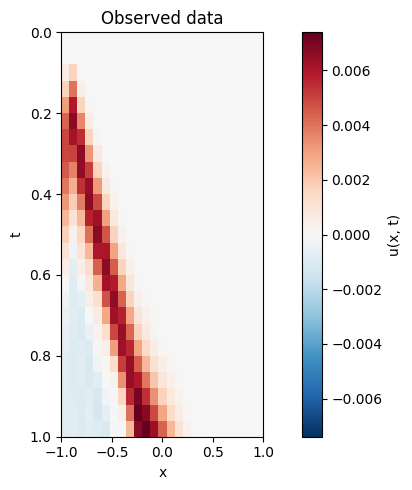

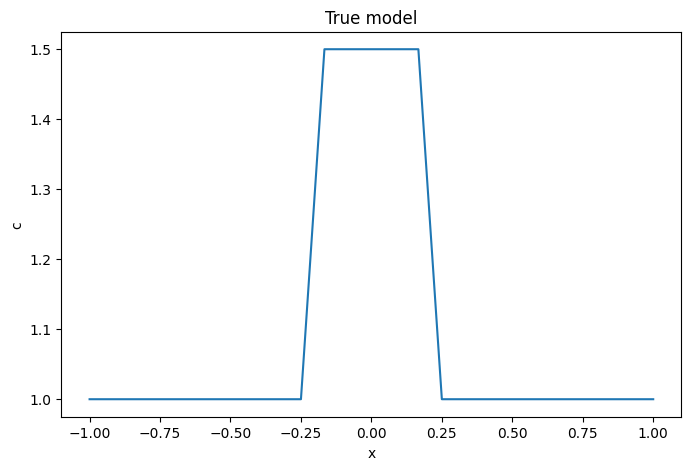

In [44]:
# wrap in a wavefield to pass to the loss
d_obs = Wavefield(init_amplitude=wavefield_true, init_wavespeed=c_true)
d_obs.show_domain("Observed data")
d_obs.show_model("True model")

In [49]:
# now we can create our functional object
functional = Discrete1DFWILoss(u=u, d_obs=d_obs)